# Predicting next year's best board game
Using Bayesian statistics

**Authors**: Lapray Lucile and Rebours Léna

**Cohort**: CPES DAC 3

**Date**: June 2026

## Introduction

This project investigates the characteristics associated with successful board games using data from BoardGameGeek (BGG). By combining information on game complexity, mechanics, domains, and publication year, we use a Bayesian regression model to identify the factors that contribute most to high player ratings. The goal is not only to explain past success but also to estimate the characteristics of the best rated board game of the year through a probabilistic framework.

### Hypotheses

- **Complexity and popular mechanics increase game ratings.** Games with higher complexity and certain widely used mechanics are more likely to receive high average ratings.

- **Board game quality has improved over time.** More recently published games tend to achieve higher ratings, suggesting a positive temporal trend that should be incorporated into future predictions.

## 1. Library import

In [ ]:
# General librairies
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data modelling
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler

## 2. Data import

We use the dataset "BGG_Data_Set.csv" published by Melissa Monfared on Kaggle. It has 20,342 rows representing 20,327 unique games. It contains information on all ranked board games on BGG as of February 2021, when BGG was scraped.

In [ ]:
df = pd.read_csv("Board_Games_Geek.csv", delimiter=';')
pd.set_option('display.max_columns', None)
df.head(5)

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Super_as_d_or
0,2399.0,Senet,-3500,2,2,30,6,664,5.82,8176,1.48,1343.0,Dice Rolling | Roll / Spin and Move,Abstract Games,0.0
1,2397.0,Backgammon,-3000,2,2,30,8,11680,6.54,1276,2.02,17747.0,Advantage Token | Betting and Bluffing | Dice ...,Abstract Games,0.0
2,5546.0,Marbles,-3000,1,0,10,4,473,4.69,20221,1.10,399.0,Flicking,Children's Games,0.0
3,1602.0,The Royal Game of Ur,-2600,2,2,30,10,549,5.90,8926,1.31,1162.0,Dice Rolling | Roll / Spin and Move | Square G...,Abstract Games,0.0
4,188.0,Go,-2200,2,2,180,8,14843,7.64,173,4.00,20398.0,Enclosure | Square Grid,Abstract Games,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17208 entries, 0 to 17207
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  17195 non-null  float64
 1   Name                17208 non-null  object 
 2   Year Published      17208 non-null  int64  
 3   Min Players         17208 non-null  int64  
 4   Max Players         17208 non-null  int64  
 5   Play Time           17208 non-null  int64  
 6   Min Age             17208 non-null  int64  
 7   Users Rated         17208 non-null  int64  
 8   Rating Average      17208 non-null  float64
 9   BGG Rank            17208 non-null  int64  
 10  Complexity Average  17208 non-null  float64
 11  Owned Users         17189 non-null  float64
 12  Mechanics           15734 non-null  object 
 13  Domains             9420 non-null   object 
 14  Super_as_d_or       17207 non-null  float64
dtypes: float64(5), int64(7), object(3)
memory usage: 2.0+

In [ ]:
# Let's see the distribution of all the informations in our dataset
df.describe()

,ID,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Super_as_d_or
count,17195.000000,17208.000000,17208.000000,17208.000000,17208.000000,17208.000000,17208.000000,17208.000000,17208.000000,17208.000000,17189.000000,17207.000000
mean,80224.592033,1977.932415,2.059391,5.693747,92.056485,9.454672,927.485065,6.272232,10553.086646,1.988529,1512.746349,0.001627
std,79026.148909,232.119513,0.677036,16.078865,578.449828,3.669709,3780.702569,0.897436,6003.618965,0.842796,5408.413964,0.040307
min,1.000000,-3500.000000,0.000000,0.000000,0.000000,0.000000,30.000000,1.050000,1.000000,0.000000,0.000000,0.000000
25%,8238.000000,1998.000000,2.000000,3.000000,25.000000,8.000000,56.000000,5.720000,5335.500000,1.330000,147.000000,0.000000
50%,39045.000000,2008.000000,2.000000,4.000000,45.000000,10.000000,123.000000,6.310000,10806.500000,1.910000,312.000000,0.000000
75%,154675.500000,2014.000000,2.000000,6.000000,90.000000,12.000000,404.000000,6.860000,15895.250000,2.540000,873.000000,0.000000
max,322451.000000,2018.000000,10.000000,999.000000,60000.000000,25.000000,102214.000000,9.580000,20344.000000,5.000000,155312.000000,1.000000


## 3. Data preparation

### 3.1 Domains

In [ ]:
# Let's see what the different domains of our games look like
domains_count = {}

for domain in df['Domains']:
    if pd.notna(domain):
      # Separate elements with a pipe in between
      elements = domain.split(' | ')

      # Count occurences
      for element in elements:
        if element in domains_count:
          domains_count[element] += 1
        else:
          domains_count[element] = 1

domains_count_df = pd.DataFrame(list(domains_count.items()),
                                columns = ['Domain', 'Occurrences']).sort_values(by='Occurrences', ascending=False)

In [ ]:
domains_count_df

,Domain,Occurrences
5,Wargames,3121
3,Family Games,1986
4,Strategy Games,1944
6,Thematic Games,1043
0,Abstract Games,1039
1,Children's Games,835
2,Party Games,558
7,Customizable Games,288


We can see that we have 8 different domains. Since it's not a large number we can create dummy variables for each domain.

In [ ]:
# We normalize the pipe separation so that there is always a space before and after
cleaned_domains = df['Domains'].str.replace(r'\s*\|\s*', '|', regex=True)

# We use pandas' get_dummies function
domains_dummies = cleaned_domains.str.get_dummies(sep='|')
domains_dummies = domains_dummies.add_prefix('Dom_')

df = pd.concat([df, domains_dummies], axis=1)

In [ ]:
df.head(3)

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Super_as_d_or,Dom_Abstract Games,Dom_Children's Games,Dom_Customizable Games,Dom_Family Games,Dom_Party Games,Dom_Strategy Games,Dom_Thematic Games,Dom_Wargames
0,2399.0,Senet,-3500,2,2,30,6,664,5.82,8176,1.48,1343.0,Dice Rolling | Roll / Spin and Move,Abstract Games,0.0,1,0,0,0,0,0,0,0
1,2397.0,Backgammon,-3000,2,2,30,8,11680,6.54,1276,2.02,17747.0,Advantage Token | Betting and Bluffing | Dice ...,Abstract Games,0.0,1,0,0,0,0,0,0,0
2,5546.0,Marbles,-3000,1,0,10,4,473,4.69,20221,1.10,399.0,Flicking,Children's Games,0.0,0,1,0,0,0,0,0,0


### 3.2 Mechanics

In [ ]:
# Let's do the same process for mechanisms
mechanics_count = {}

for mechanism in df['Mechanics']:
    if pd.notna(mechanism):
        elements = mechanism.split(' | ')

        for element in elements:
            if element in mechanics_count:
                mechanics_count[element] += 1
            else:
                mechanics_count[element] = 1

mechanics_count_df = pd.DataFrame(list(mechanics_count.items()),
                                  columns = ['Mechanism', 'Occurrences']).sort_values(by='Occurrences', ascending=False)

In [ ]:
# Let's see how many different mechanisms we have
mechanics_count_df

,Mechanism,Occurrences
0,Dice Rolling,4794
17,Hand Management,3358
18,Set Collection,2176
40,Hexagon Grid,2126
37,Variable Player Powers,1879
...,...,...
152,Selection Order Bid,3
180,Auction: Dutch Priority,3
177,Passed Action Token,3
143,Auction: English,1


We have 182 different rows so 182 unique mechanisms, which is too large a number for our small Bayesian model. Hence, we won't create dummies for all mechanisms but we will only take into account the top 10 mechanisms with the most occurences

In [ ]:
mechanics_count_df_filtered = mechanics_count_df.head(10)
top_10_mechanics = mechanics_count_df_filtered['Mechanism'].tolist()
top_10_mechanics

['Dice Rolling',
 'Hand Management',
 'Set Collection',
 'Hexagon Grid',
 'Variable Player Powers',
 'Simulation',
 'Card Drafting',
 'Tile Placement',
 'Modular Board',
 'Roll / Spin and Move']

In [ ]:
# We create our dummies variables for mechanics
cleaned_mechanics = df['Mechanics'].str.replace(r'\s*\|\s*', '|', regex=True)
mechanics_dummies = cleaned_mechanics.str.get_dummies(sep='|')

# Now that we have dummies for all mechanics, let's filter it to only keep the top 10
columns_to_keep = [mech for mech in top_10_mechanics if mech in mechanics_dummies.columns]
filtered_dummies = mechanics_dummies[columns_to_keep]
filtered_dummies = filtered_dummies.add_prefix('Mech_')

df = pd.concat([df, filtered_dummies], axis=1)

In [ ]:
df.head(3)

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Super_as_d_or,Dom_Abstract Games,Dom_Children's Games,Dom_Customizable Games,Dom_Family Games,Dom_Party Games,Dom_Strategy Games,Dom_Thematic Games,Dom_Wargames,Mech_Dice Rolling,Mech_Hand Management,Mech_Set Collection,Mech_Hexagon Grid,Mech_Variable Player Powers,Mech_Simulation,Mech_Card Drafting,Mech_Tile Placement,Mech_Modular Board,Mech_Roll / Spin and Move
0,2399.0,Senet,-3500,2,2,30,6,664,5.82,8176,1.48,1343.0,Dice Rolling | Roll / Spin and Move,Abstract Games,0.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
1,2397.0,Backgammon,-3000,2,2,30,8,11680,6.54,1276,2.02,17747.0,Advantage Token | Betting and Bluffing | Dice ...,Abstract Games,0.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
2,5546.0,Marbles,-3000,1,0,10,4,473,4.69,20221,1.10,399.0,Flicking,Children's Games,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 4. Data cleaning

We have decided to be strict on the data cleaning process. We have a sufficiently large sample that allow us to remove observations with uncertain values.

### 4.1 Play Time

After manually checking on a few games, we came to the realisation that some very long games had values of 10+ hours because of mistakes. for instance, 10h or 20h long games were sometimes actually 1h or 2h games. Because of the uncertainty this represents, we decided to remove all observations that were longer than 9 hours.

0 is also a suspicious value, hence we decided to also remove all games featuring it.

In [ ]:
print("Number of games removed : ",
      len( df[df['Play Time'] > 540]) +
      len( df[df['Play Time'] == 0] ))
# 540 minutes = 9 hours
df[df['Play Time'] > 540] = np.nan
df[df['Play Time'] == 0] = np.nan

Number of games removed :  683


In [ ]:
df['Play Time'].describe()

,Play Time
count,16525.000000
mean,70.701301
std,74.869759
min,1.000000
25%,30.000000
50%,45.000000
75%,90.000000
max,540.000000


### 4.2 Year published

There are several games with a year of publication older than 1850, which seems uncertain. Moreover, since our end goal is to predict the best game for next year (because of our dataset, that means the best rated game of 2022), older games are less interesting.

In [ ]:
print("Number of games removed : ", len( df[df['Year Published'] < 1850] ))
df[df['Year Published'] < 1850] = np.nan

Number of games removed :  232


In [ ]:
df['Year Published'].describe()

,Year Published
count,16293.000000
mean,2003.799423
std,14.809964
min,1850.000000
25%,1999.000000
50%,2008.000000
75%,2014.000000
max,2018.000000


### 4.3 Min players & max players

Similarly as for Play Time, we manually checked the actual Maximum number of players and found that large number were sometimes error.

Moreover, very large number of players often mean "no maxmimum limit of players", and can be encoded with 99, 100, 200 or 999 for instance. This induces a problem of scale, because 999 mustn't be considered 10 times the amount of 100. And the difference between 9 and 10 players cannot be undrestood as 1% of the difference between 10 and 100.

Finally, there is the problem of the 0s that are impossible artifacts. Hence, we remove all of these outliers and strange values.

In [ ]:
print("Number of games removed : ",
      len( df[df['Max Players'] >= 99] ) +
      len( df[df['Max Players'] == 0] ))

df[df['Max Players'] >= 99] = np.nan
df[df['Max Players'] == 0] = np.nan

Number of games removed :  219


In [ ]:
df['Max Players'].describe()

,Max Players
count,16074.000000
mean,4.850442
std,3.316657
min,1.000000
25%,4.000000
50%,4.000000
75%,6.000000
max,75.000000


In [ ]:
print("Number of games removed : ", len( df[df['Min Players'] == 0] ))
df[df['Min Players'] == 0] = np.nan

Number of games removed :  4


In [ ]:
df['Min Players'].describe()

,Min Players
count,16070.00000
mean,2.06397
std,0.65795
min,1.00000
25%,2.00000
50%,2.00000
75%,2.00000
max,10.00000


### 4.4 General NAs clean

In [ ]:
print("Number of games removed : ", len( df ) - len( df.dropna() ))
df = df.dropna()

Number of games removed :  8776


In [ ]:
df.describe()

,ID,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Super_as_d_or,Dom_Abstract Games,Dom_Children's Games,Dom_Customizable Games,Dom_Family Games,Dom_Party Games,Dom_Strategy Games,Dom_Thematic Games,Dom_Wargames,Mech_Dice Rolling,Mech_Hand Management,Mech_Set Collection,Mech_Hexagon Grid,Mech_Variable Player Powers,Mech_Simulation,Mech_Card Drafting,Mech_Tile Placement,Mech_Modular Board,Mech_Roll / Spin and Move
count,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.00000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000,8432.000000
mean,61646.474620,2001.657732,1.982448,4.322936,93.481262,9.905242,1725.352467,6.537367,7782.624526,2.282088,2708.711101,0.002965,0.098435,0.080289,0.027989,0.220588,0.056570,0.226755,0.11907,0.325664,0.362666,0.199122,0.127372,0.211219,0.129507,0.165323,0.084915,0.095351,0.094639,0.054554
std,70392.373484,15.267279,0.604161,3.018695,90.527588,3.491646,5249.163645,0.802732,5915.257717,0.821926,7472.698018,0.054373,0.297919,0.271757,0.164950,0.414668,0.231033,0.418758,0.32389,0.468650,0.480798,0.399364,0.333409,0.408198,0.335780,0.371493,0.278771,0.293717,0.292734,0.227121
min,1.000000,1850.000000,1.000000,1.000000,1.000000,0.000000,30.000000,2.830000,1.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5940.750000,1995.000000,2.000000,2.000000,30.000000,8.000000,91.000000,6.050000,2644.750000,1.630000,261.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25743.500000,2006.000000,2.000000,4.000000,60.000000,10.000000,305.000000,6.570000,6428.500000,2.250000,677.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,121303.750000,2012.000000,2.000000,5.000000,120.000000,12.000000,1152.500000,7.080000,12337.500000,2.850000,2064.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,297985.000000,2018.000000,8.000000,75.000000,540.000000,21.000000,102214.000000,9.230000,20342.000000,5.000000,155312.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 5. Data description

In [ ]:
# Harmonize visual theme of figures
sns.set_theme(context = 'notebook', style='darkgrid', palette='viridis', font='serif')

### 5.1 Continuous variables

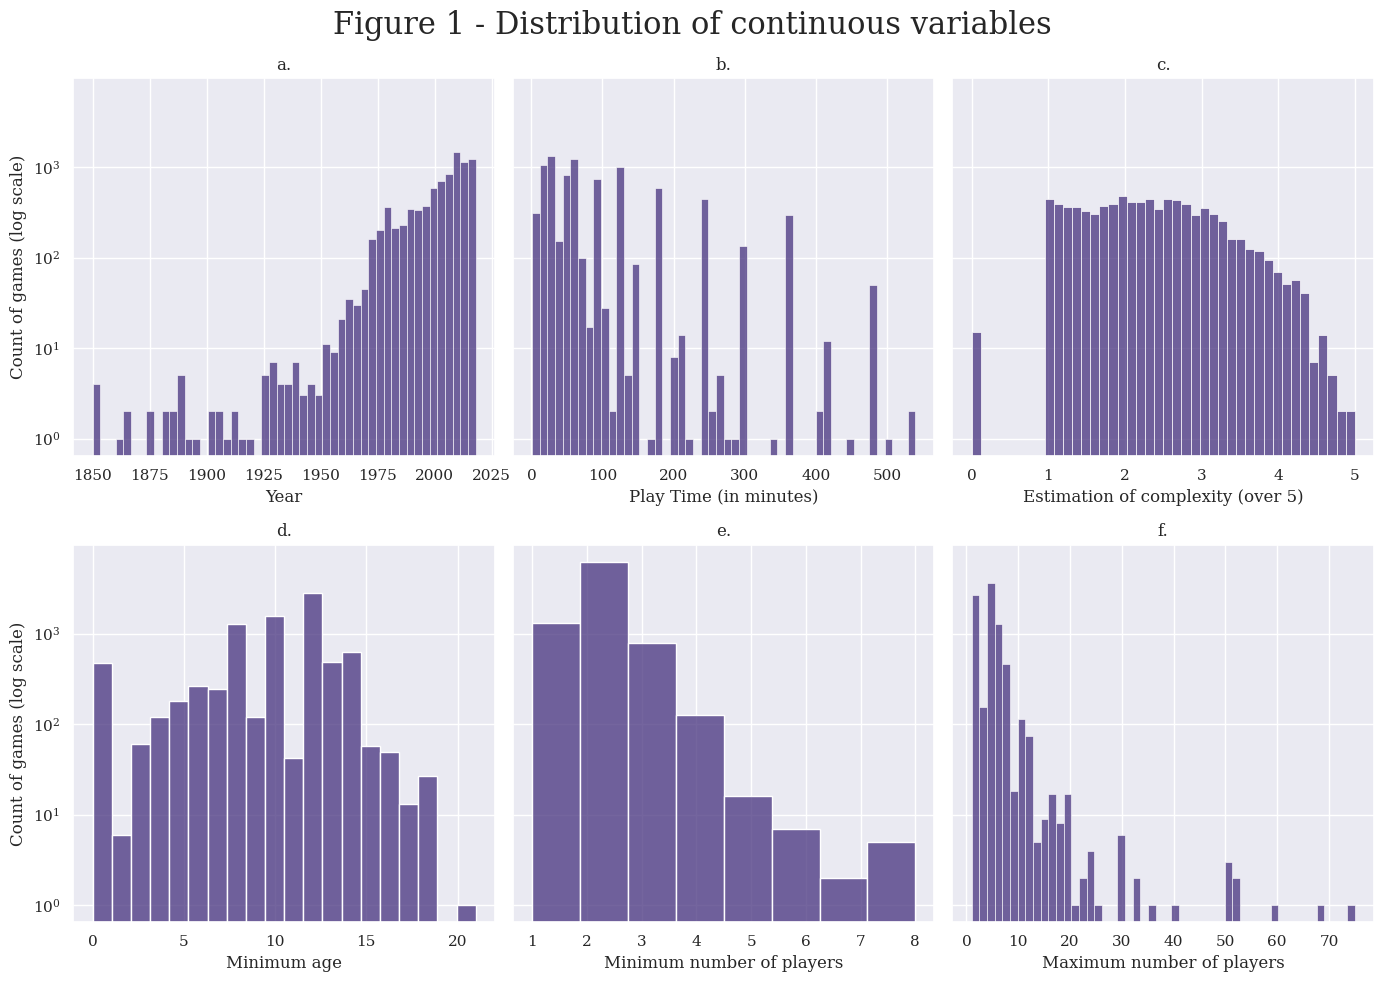

In [ ]:
fig1, axs = plt.subplots(2, 3, figsize=(14, 10), sharey=True)
fig1.suptitle("Figure 1 - Distribution of continuous variables", size = 22)

sns.histplot(x = df['Year Published'], ax = axs[0, 0], bins=50)
axs[0, 0].set_title("a.")
axs[0, 0].set_xlabel("Year")
axs[0, 0].set_ylabel("Count of games (log scale)")
axs[0, 0].set_yscale('log')

sns.histplot(x = df['Play Time'], ax = axs[0, 1], bins=50)
axs[0, 1].set_title("b.")
axs[0, 1].set_xlabel("Play Time (in minutes)")
axs[0, 1].set_ylabel("Count of games (log scale)")
axs[0, 1].set_yscale('log')

sns.histplot(x = df['Complexity Average'], ax = axs[0, 2])
axs[0, 2].set_title("c.")
axs[0, 2].set_xlabel("Estimation of complexity (over 5)")
axs[0, 2].set_ylabel("Count of games (log scale)")
axs[0, 2].set_yscale('log')

sns.histplot(x = df['Min Age'], ax=axs[1, 0], bins=20)
axs[1, 0].set_title("d.")
axs[1, 0].set_xlabel("Minimum age")
axs[1, 0].set_ylabel("Count of games (log scale)")
axs[1, 0].set_yscale('log')

sns.histplot(x = df['Min Players'], ax=axs[1, 1], bins=8)
axs[1, 1].set_title("e.")
axs[1, 1].set_xlabel("Minimum number of players")
axs[1, 1].set_ylabel("Count of games (log scale)")
axs[1, 1].set_yscale('log')

sns.histplot(x = df['Max Players'], ax=axs[1, 2], bins=50)
axs[1, 2].set_title("f.")
axs[1, 2].set_xlabel("Maximum number of players")
axs[1, 2].set_ylabel("Count of games (log scale)")
axs[1, 2].set_yscale('log')

plt.tight_layout()
#plt.savefig('fig1.png')
plt.show()

### 5.2 Categorical variables

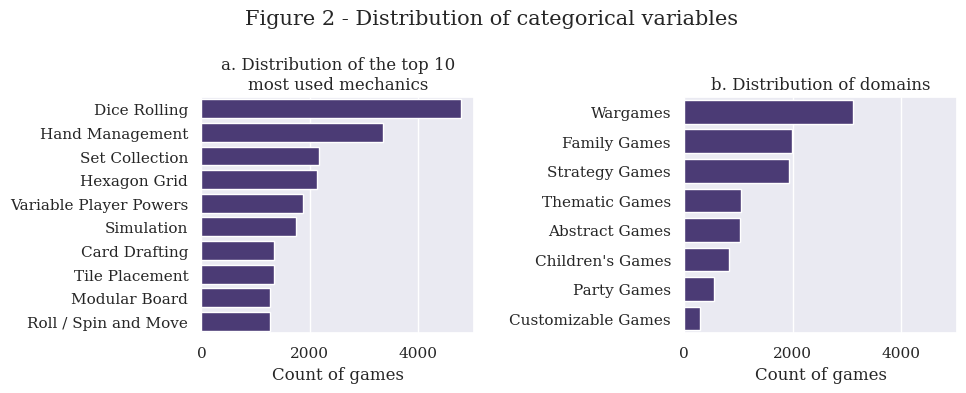

In [ ]:
fig2, axs = plt.subplots(1, 2, figsize=(10, 4), sharex = True)
fig2.suptitle("Figure 2 - Distribution of categorical variables", size=15)

# Figure 1
mechanism_top10 = mechanics_count_df_filtered['Mechanism']
occurrences_top10 = mechanics_count_df_filtered['Occurrences']

sns.barplot(y=mechanism_top10, x=occurrences_top10, ax=axs[0])
axs[0].set_title("a. Distribution of the top 10\nmost used mechanics")
axs[0].set_xlabel("Count of games")
axs[0].set_ylabel("")


# Figure 2
domains = domains_count_df['Domain']
occurrences_dom = domains_count_df['Occurrences']

sns.barplot(y=domains, x=occurrences_dom, ax=axs[1])
axs[1].set_title("b. Distribution of domains")
axs[1].set_xlabel("Count of games")
axs[1].set_ylabel("")


plt.tight_layout()
#plt.savefig('fig2.png')
plt.show()

### 5.3 Predicted variable

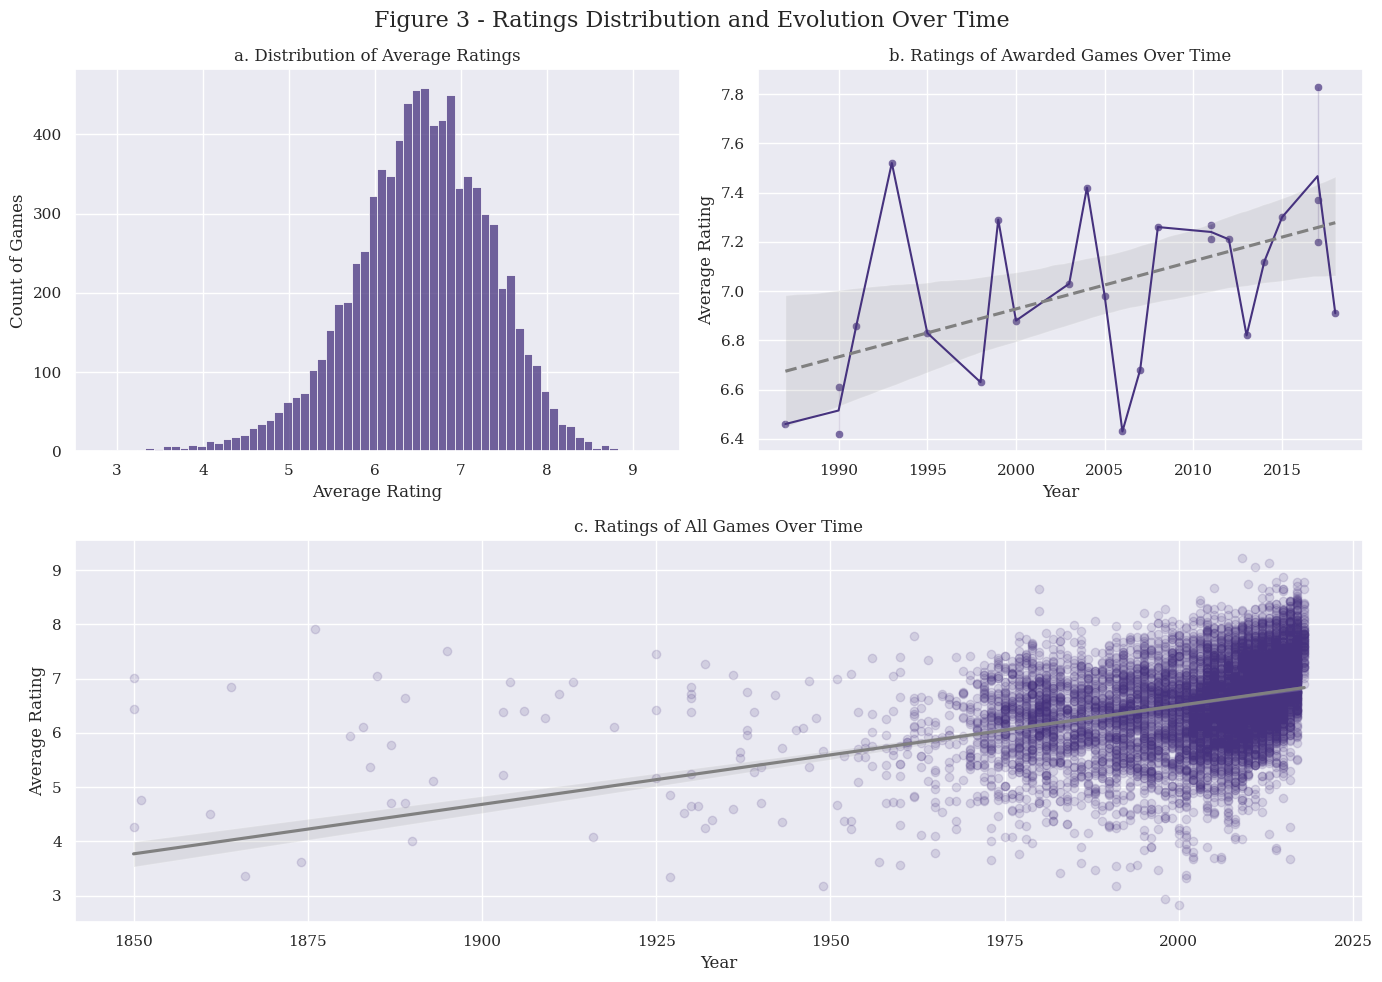

In [ ]:
# Panel of the plots about ratings
fig3 = plt.figure(figsize=(14, 10))
fig3.suptitle("Figure 3 - Ratings Distribution and Evolution Over Time", fontsize=16)
gs = fig3.add_gridspec(2, 2)

# Top row
ax1 = fig3.add_subplot(gs[0, 0])
ax2 = fig3.add_subplot(gs[0, 1])
# Bottom row
ax3 = fig3.add_subplot(gs[1, :])

# Figure 1
sns.histplot(
    data=df,
    x='Rating Average',
    ax=ax1)

ax1.set_title("a. Distribution of Average Ratings")
ax1.set_xlabel("Average Rating")
ax1.set_ylabel("Count of Games")

# Figure 2
df_prime = df[df['Super_as_d_or'] == 1]

sns.lineplot(
    data=df_prime,
    x='Year Published',
    y='Rating Average',
    ax=ax2)

sns.scatterplot(
    data=df_prime,
    x='Year Published',
    y='Rating Average',
    alpha=0.7,
    ax=ax2)

sns.regplot(
    data=df_prime,
    x='Year Published',
    y='Rating Average',
    scatter=False,
    color='grey',
    line_kws={'linestyle': '--'},
    ax=ax2)

ax2.set_title("b. Ratings of Awarded Games Over Time")
ax2.set_xlabel("Year")
ax2.set_ylabel("Average Rating")

# Figure 3
sns.regplot(
    data=df,
    x='Year Published',
    y='Rating Average',
    scatter_kws={'alpha': 0.15},
    line_kws={'color': 'grey'},
    ax=ax3
)

ax3.set_title("c. Ratings of All Games Over Time")
ax3.set_xlabel("Year")
ax3.set_ylabel("Average Rating")

plt.tight_layout()
#plt.savefig('fig3_panel.png')
plt.show()

## 6. Data modelling

### 6.1 Feature selection

In [ ]:
# De-fragmentation of the dataframe in the memory
df = df.copy()

In [ ]:
df['Time_Offset'] = df['Year Published'] - 2021

cont_cols = ['Play Time', 'Complexity Average',
             'Min Age', 'Min Players', 'Max Players']

dom_cols = [col for col in df.columns if col.startswith('Dom_')]
mech_cols = [col for col in df.columns if col.startswith('Mech_')]

### 6.2 Data standardization

In [ ]:
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(df[cont_cols])

### 6.3 Bayesian model training

In [ ]:
# We extract NumPy arrays for fast matrix multiplication in PyMC
time_array = df['Time_Offset'].values
X_dom = df[dom_cols].values
X_mech = df[mech_cols].values
y = df['Rating Average'].values

In [ ]:
with pm.Model() as trend_model:

    # PRIORS
    alpha = pm.Normal('alpha', mu=y.mean(), sigma=1.0)

    # Coefficients
    beta_year = pm.Normal('beta_year', mu=0, sigma=0.5)
    beta_cont = pm.Normal('beta_cont', mu=0, sigma=1.0, shape=len(cont_cols))
    beta_dom = pm.Normal('beta_dom', mu=0, sigma=1.0, shape=len(dom_cols))
    beta_mech = pm.Normal('beta_mech', mu=0, sigma=1.0, shape=len(mech_cols))

    # Trend velocities
    # We use a tighter sigma here because trend shifts per year are usually small
    gamma_cont = pm.Normal('gamma_cont', mu=0, sigma=0.2, shape=len(cont_cols))
    gamma_dom = pm.Normal('gamma_dom', mu=0, sigma=0.2, shape=len(dom_cols))
    gamma_mech = pm.Normal('gamma_mech', mu=0, sigma=0.2, shape=len(mech_cols))

    sigma = pm.HalfNormal('sigma', sigma=1.0)

    # DYNAMIC EQUATIONS
    # We calculate the effective coefficient for every single row based on its year
    effective_cont = beta_cont + (gamma_cont * time_array[:, None])
    effective_dom = beta_dom + (gamma_dom * time_array[:, None])
    effective_mech = beta_mech + (gamma_mech * time_array[:, None])

    # Multiply the effective coefficients by the actual game data and sum them up
    mu = (alpha +
          (beta_year * time_array) +
          (effective_cont * X_cont_scaled).sum(axis=1) +
          (effective_dom * X_dom).sum(axis=1) +
          (effective_mech * X_mech).sum(axis=1))

    # LIKELIHOOD
    rating = pm.Normal('rating', mu=mu, sigma=sigma, observed=y)

    # SAMPLING
    print("Sampling dynamic trend model")
    trace_trends = pm.sample(draws=1500,
                             tune=1000,
                             chains=4,
                             cores=4,
                             target_accept=0.9)

Sampling dynamic trend model...


Output()

In [ ]:
summary = az.summary(trace_trends, hdi_prob=0.94)

In [92]:
summary = az.summary(trace_trends)
rhat_column = summary['r_hat']

bad_convergence = summary[summary['r_hat'] > 1.01]
if not bad_convergence.empty:
    print(bad_convergence['r_hat'])
else:
    print("All parameters converged successfully (R-hat <= 1.01).")

All parameters converged successfully (R-hat <= 1.01).


In [93]:
rhat_column

,r_hat
alpha,1.0
beta_cont[0],1.0
beta_cont[1],1.0
beta_cont[2],1.0
beta_cont[3],1.0
beta_cont[4],1.0
beta_dom[0],1.0
beta_dom[1],1.0
beta_dom[2],1.0
beta_dom[3],1.0


## 7. Results

### 7.1 Table

In [67]:
results = []

def extract_features(columns_list, beta_name, gamma_name, category):
    for i, col in enumerate(columns_list):
        # Cleaning names for clarity
        clean_name = col.replace('Mech_', '').replace('Dom_', '')

        results.append({
            'Feature': clean_name,
            'Category': category,
            'Impact_2021': summary.loc[f'{beta_name}[{i}]', 'mean'],
            'Impact_HDI_3': summary.loc[f'{beta_name}[{i}]', 'hdi_3%'],
            'Impact_HDI_97': summary.loc[f'{beta_name}[{i}]', 'hdi_97%'],
            'Yearly_Trend': summary.loc[f'{gamma_name}[{i}]', 'mean'],
            'Trend_HDI_3': summary.loc[f'{gamma_name}[{i}]', 'hdi_3%'],
            'Trend_HDI_97': summary.loc[f'{gamma_name}[{i}]', 'hdi_97%'] })

extract_features(cont_cols, 'beta_cont', 'gamma_cont', 'Continuous (Std)')
extract_features(dom_cols, 'beta_dom', 'gamma_dom', 'Domain')
extract_features(mech_cols, 'beta_mech', 'gamma_mech', 'Mechanic')

df_all = pd.DataFrame(results)

In [88]:
df_sorted = df_all.sort_values(by='Impact_2021', ascending=False).reset_index(drop=True)
df_sorted[['Feature', 'Category', 'Impact_2021', 'Yearly_Trend']]

,Feature,Category,Impact_2021,Yearly_Trend
0,Customizable Games,Domain,0.420,0.042
1,Complexity Average,Continuous (Std),0.363,0.001
2,Party Games,Domain,0.267,0.011
3,Card Drafting,Mechanic,0.182,0.008
4,Dice Rolling,Mechanic,0.148,0.007
5,Variable Player Powers,Mechanic,0.136,0.004
6,Hexagon Grid,Mechanic,0.126,0.005
7,Simulation,Mechanic,0.085,-0.003
8,Wargames,Domain,0.046,0.003
9,Strategy Games,Domain,0.030,0.001


In [90]:
# Evaluate significance: The effect is significant if the 94% HDI does not cross zero
df_sorted['Significant_Impact'] = ((df_sorted['Impact_HDI_3'] > 0) | (df_sorted['Impact_HDI_97'] < 0))
df_sorted['Significant_Trend'] = ((df_sorted['Trend_HDI_3'] > 0) | (df_sorted['Trend_HDI_97'] < 0))

# Map boolean values to readable strings for the table
df_sorted['Significant_Impact'] = df_sorted['Significant_Impact'].map({True: 'Yes', False: 'No'})
df_sorted['Significant_Trend'] = df_sorted['Significant_Trend'].map({True: 'Yes', False: 'No'})

df_sorted[['Feature', 'Category', 'Impact_2021', 'Significant_Impact', 'Yearly_Trend', 'Significant_Trend']]

,Feature,Category,Impact_2021,Significant_Impact,Yearly_Trend,Significant_Trend
0,Customizable Games,Domain,0.420,Yes,0.042,Yes
1,Complexity Average,Continuous (Std),0.363,Yes,0.001,No
2,Party Games,Domain,0.267,Yes,0.011,Yes
3,Card Drafting,Mechanic,0.182,Yes,0.008,Yes
4,Dice Rolling,Mechanic,0.148,Yes,0.007,Yes
5,Variable Player Powers,Mechanic,0.136,Yes,0.004,No
6,Hexagon Grid,Mechanic,0.126,Yes,0.005,Yes
7,Simulation,Mechanic,0.085,Yes,-0.003,No
8,Wargames,Domain,0.046,No,0.003,No
9,Strategy Games,Domain,0.030,No,0.001,No


### 7.2 Time trends - quadrant plots

In [80]:
colors = ['darkorchid', 'blueviolet', 'slateblue']

In [72]:
top_to_annotate = df_all.reindex(df_all['Impact_2021'].abs().sort_values(ascending=False).index).head(10)

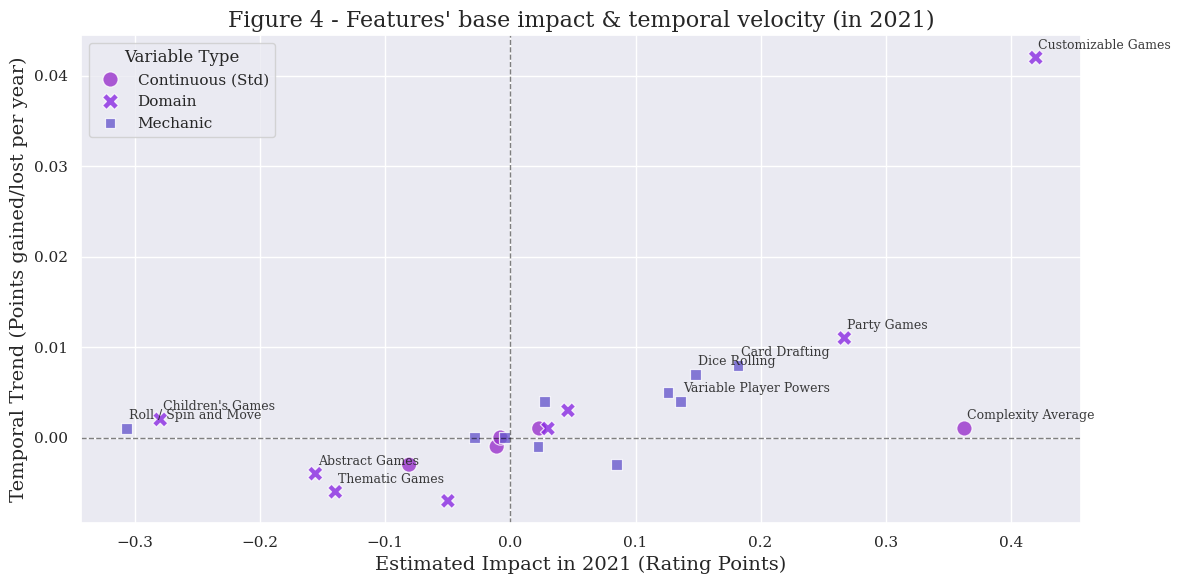

In [87]:
plt.figure(figsize=(12, 6))
plt.title("Figure 4 - Features' base impact & temporal velocity (in 2021)", fontsize=16)

# Multi-category scatter plot
sns.scatterplot(
    data=df_all,
    x='Impact_2021',
    y='Yearly_Trend',
    hue='Category',
    style='Category',
    s=120,
    alpha=0.8,
    palette=colors,
    edgecolor='white'
)

# Zero lines (Null hypothesis)
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Targeted annotation
for i in range(len(top_to_annotate)):
    plt.text(
        top_to_annotate['Impact_2021'].iloc[i] + 0.002,
        top_to_annotate['Yearly_Trend'].iloc[i] + 0.001,
        top_to_annotate['Feature'].iloc[i],
        fontsize=9,
        alpha=0.9
    )

plt.xlabel("Estimated Impact in 2021 (Rating Points)", fontsize=14)
plt.ylabel("Temporal Trend (Points gained/lost per year)", fontsize=14)
plt.legend(title="Variable Type", loc='upper left')

plt.tight_layout()
#plt.savefig('fig4.png')
plt.show()

### 7.3 Forest plots

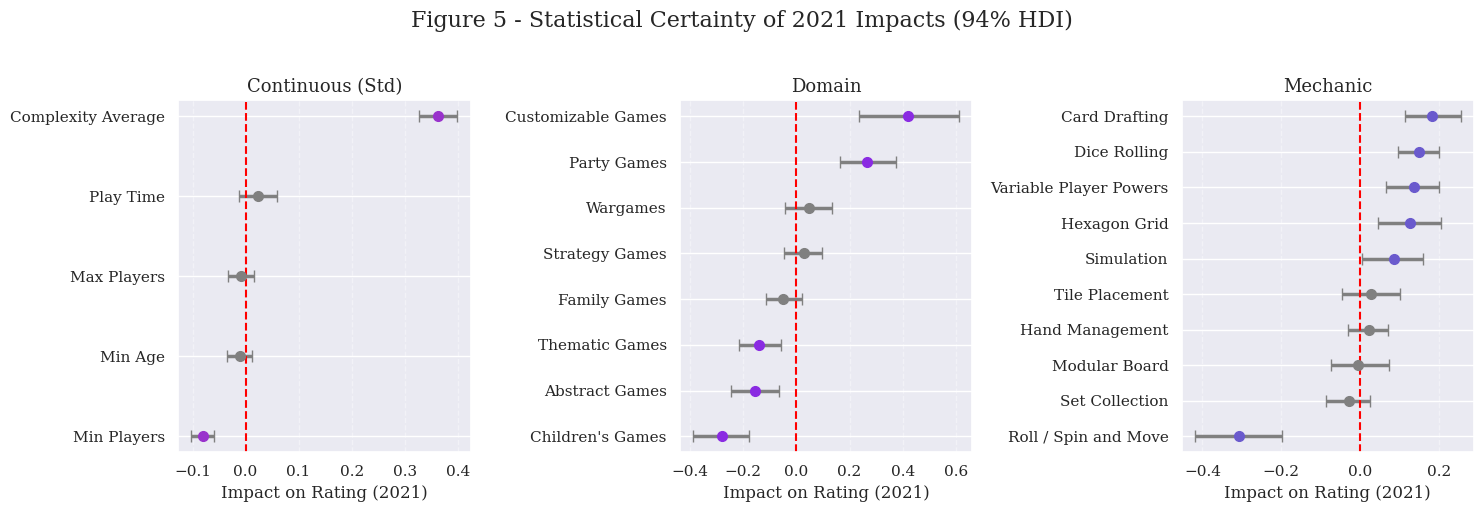

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=False)
fig.suptitle("Figure 5 - Statistical Certainty of 2021 Impacts (94% HDI)", fontsize=16, y=1.02)

categories = ['Continuous (Std)', 'Domain', 'Mechanic']

for idx, (cat, color) in enumerate(zip(categories, colors)):
    # Isolate data for the current category
    cat_df = df_all[df_all['Category'] == cat].copy()
    cat_df = cat_df.sort_values(by='Impact_2021', ascending=True).reset_index(drop=True)

    # Set y-ticks explicitly to ensure the order is maintained during the loop
    axes[idx].set_yticks(range(len(cat_df)))
    axes[idx].set_yticklabels(cat_df['Feature'])

    for i, row in cat_df.iterrows():
        # Check statistical significance
        is_significant = (row['Impact_HDI_3'] > 0) or (row['Impact_HDI_97'] < 0)
        # Apply grey if not significant
        marker_color = color if is_significant else 'gray'
        # Calculate error bars
        xerr_lower = row['Impact_2021'] - row['Impact_HDI_3']
        xerr_upper = row['Impact_HDI_97'] - row['Impact_2021']

        axes[idx].errorbar(
            x=row['Impact_2021'],
            y=i,
            xerr=[[xerr_lower], [xerr_upper]],
            fmt='o',
            color=marker_color,
            ecolor='gray',
            capsize=4,
            elinewidth=2.5,
            markersize=7
        )

    # Subplot aesthetics
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f"{cat}", fontsize=13)
    axes[idx].set_xlabel("Impact on Rating (2021)")
    axes[idx].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
#plt.savefig('fig5.png')
plt.show()